# 2.0 Data Exploration and Information Share
---
---

## Online Retail II UCI

The staging table stg_online_retail_orders is from a real online retail transaction data set with two years worth of information. The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

We split this notebook into '**Data Exploration**', '**Data Distribution**' and '**Data Preparation & Technique**' sections to serve as a Wiki for knowledge-share and cross-functional collaboration.

- **Data Exploration:** Understand how the information works such as business process, one-to-one mappings of fields, inconsistencies in fields, outliers, duplications, typos, errors and such like.
- **Data Distribution:** Run distributions to understand overarching trends, check the quality of the data.
- **Data Preparation & Techniques:** Section comprising of How To's for Data Segmentation, Analysis and modelling including colleague feedback on business logic, process improvement and best practices.

---
**Table Specifications**
- Table Location: data/interim
- Table name: stg_online_retail_orders
- Fields: 10
- Rows: 1.067,371
- Approximate Memory Use: 74.3 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | String | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| String | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | String | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Integer 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | String | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | String | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Boolean | This is a True/False flag | False |

---
### Document Log

##### Data Exploration:
| **Tag** | **Topic** | **Description** | **Contributor** | **Date** |
| :--- | :--- | :--- | :--- | :--- |

##### Data Distributions:
| **Tag** | **Topic** | **Description** | **Contributor** | **Date** |
| :--- | :--- | :--- | :--- | :--- |

##### Data Preparation & Techniques:
| **Tag** | **Topic** | **Description** | **Contributor** | **Date** |
| :--- | :--- | :--- | :--- | :--- |

*(In a team environment, we would also include Revision Date, Change Added and Who By for existing tags)*

---
# Load Data
---
---
First we need to load the data ready for Exploration Phase:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/stg_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("Importing df_stg_online_retail_orders Parquet to dataframe df_stg_online_retail_orders ..")
    df_stg_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_stg_online_retail_orders complete.")

Importing df_stg_online_retail_orders Parquet to dataframe df_stg_online_retail_orders ..
✅ Data loaded to dataframe df_stg_online_retail_orders complete.


---
# Data Exploration
---
---

We look at what is inside the fields, their relationship to each other such as one-to-one mappings and determining any category 

**First lets make a new interim dataframe:**

In [2]:
df_cleansed_retail_orders =   df_stg_online_retail_orders
print("✅ Data copied to dataframe df_cleansed_retail_orders.")

✅ Data copied to dataframe df_cleansed_retail_orders.


---
### Invoice Codes:
- 1. Are there duplicate invoice codes across the time series?
- 2. How do the 7 varchar long invoice codes work (most flagged as cancelled)?

#### 1. We check for duplicate invoice numbers across the date range:

In [3]:
# ==========================
# Let's check the actual invoice dates for these duplicates

# Get unique Invoice + InvoiceDate combinations
invoice_fields = df_cleansed_retail_orders[['Invoice', 'InvoiceDate']].drop_duplicates()

# 2. Count occurrences of each Invoice in this distinct list
invoice_counts = invoice_fields['Invoice'].value_counts()

# 3. Filter for Invoices that appear on 2 or more distinct InvoiceDates
duplicated_invoices_list = invoice_counts[invoice_counts >= 2].index.tolist()

# 4. Create a dataframe of just these duplicated invoices and sort ascending by date
duplicated_invoices_df = invoice_fields[invoice_fields['Invoice'].isin(duplicated_invoices_list)]
duplicated_invoices_df = duplicated_invoices_df.sort_values(by=['Invoice', 'InvoiceDate'], ascending=[True, True])

# Display the unique Invoice and Date combinations
print(f"Found {len(duplicated_invoices_list)} Invoices with multiple distinct InvoiceDates.")
print("\nDuplicated Invoices and their Dates (Ordered by Date Ascending):")
display(duplicated_invoices_df)


# ==========================
# Then lets view the time differences formatted as days, hours, minutes to spot anything obvious

# Group by invoice to find the first and last timestamp
time_diff_df = duplicated_invoices_df.groupby('Invoice')['InvoiceDate'].agg(['min', 'max']).reset_index()

# Calculate difference
time_diff_df['TimeDelta'] = time_diff_df['max'] - time_diff_df['min']

# Format as xd, xh, xm using timedelta components
time_diff_df['DateDiff'] = time_diff_df['TimeDelta'].apply(
    lambda td: f"{td.components.days}d, {td.components.hours}h, {td.components.minutes}m"
)

# Display just Invoice and the formatted DateDiff
print("\nTime Difference between First and Last log for Duplicated Invoices:")
display(time_diff_df[['Invoice', 'DateDiff']])


# ==========================
# Then lets just summarise the invoices by time difference in days, hours, minutes to quantify it

# Create a summary by DateDiff
# Group by both TimeDelta and text field DateDiff
summary_df = time_diff_df.groupby(['TimeDelta', 'DateDiff']).size().reset_index(name='total')

# Sort by TimeDelta
summary_df = summary_df.sort_values('TimeDelta', ascending=True)

# Return the summary
summary_df = summary_df[['DateDiff', 'total']]

display(summary_df)

Found 83 Invoices with multiple distinct InvoiceDates.

Duplicated Invoices and their Dates (Ordered by Date Ascending):


,Invoice,InvoiceDate
41630,492807,2009-12-20 12:28:00
41655,492807,2009-12-20 12:29:00
52310,494166,2010-01-12 09:47:00
52516,494166,2010-01-12 09:48:00
110024,499967,2010-03-03 14:06:00
...,...,...
988724,576057,2011-11-13 15:06:00
1024386,578548,2011-11-24 15:02:00
1024452,578548,2011-11-24 15:03:00
634376,C545569,2011-03-03 16:25:00



Time Difference between First and Last log for Duplicated Invoices:


,Invoice,DateDiff
0,492807,"0d, 0h, 1m"
1,494166,"0d, 0h, 1m"
2,499967,"0d, 0h, 1m"
3,500353,"0d, 0h, 1m"
4,500827,"0d, 0h, 1m"
...,...,...
78,571735,"0d, 0h, 1m"
79,574076,"0d, 0h, 1m"
80,576057,"0d, 0h, 1m"
81,578548,"0d, 0h, 1m"


,DateDiff,total
0,"0d, 0h, 1m",80
1,"0d, 0h, 2m",1
2,"0d, 0h, 4m",1
3,"0d, 0h, 9m",1


---
The 3 things we see from the above are:
- 166 rows of duplicates on 83 invoice numbers
- If we format to day, hour, minute it looks like there are many that are 1 minute
- If we summarise by DateDiff all 83 invoices with duplication are less than 10 minutes apart like some "system timing issue".

We can see that invoice numbers are not being recycled on later dates in this data extract.

Given that each invoice is unique to within the same several minutes, we clean this up to help with future analysis.

## Cleanse rule 1
**We set all invoices to the minimum invoice date:**

In [4]:
df_cleansed_retail_orders['InvoiceDate'] = df_cleansed_retail_orders.groupby('Invoice')['InvoiceDate'].transform('min')

print("✅ Cleanse 1: All line items for a given Invoice now share the same Invoice Date timestamp.")

✅ Cleanse 1: All line items for a given Invoice now share the same Invoice Date timestamp.


---
---
#### 2. How do the 7 varchar long invoice codes work (most flagged as cancelled)?

In step 1 of the Data Clean and Stage ETL we had  1,047,871 '6 digit long' invoices and 19,500 '7 varchar long' invoices but we only flagged 19,494 as cancelled.

**What are the missing 6?**

In [5]:

# Identify invoices starting with C
c_at_start = df_cleansed_retail_orders['Invoice'].str.startswith('C')

# Identify all invoices that are varchar 7
is_length_7 = df_cleansed_retail_orders['Invoice'].str.len() == 7

# Identify invoices that are varchar 7 and do not start with C
missing_invoices = is_length_7 & (~c_at_start)

# Filter the dataframe to only those rows
missing_rows = df_cleansed_retail_orders[missing_invoices]

# Display the results
print("\nThe missing 6 Invoices:")
print(missing_rows)

# Below we check the stock codes for bad debt and they match the other method above, IE that we don't find additional bad debt
# df_filtered = df_cleansed_retail_orders[df_cleansed_retail_orders['StockCode'] == 'B']
# display_df = df_filtered.head(10).copy()
# display(display_df)


The missing 6 Invoices:
        Invoice StockCode      Description  Quantity         InvoiceDate  \
179403  A506401         B  ADJUST BAD DEBT         1 2010-04-29 13:36:00   
276274  A516228         B  ADJUST BAD DEBT         1 2010-07-19 11:24:00   
403472  A528059         B  ADJUST BAD DEBT         1 2010-10-20 12:04:00   
825443  A563185         B  ADJUST BAD DEBT         1 2011-08-12 14:50:00   
825444  A563186         B  ADJUST BAD DEBT         1 2011-08-12 14:51:00   
825445  A563187         B  ADJUST BAD DEBT         1 2011-08-12 14:52:00   

        UnitPrice  TotalPrice CustomerHashID         Country  Cancellation  
179403  -53594.36   -53594.36            NaN  UNITED KINGDOM         False  
276274  -44031.79   -44031.79            NaN  UNITED KINGDOM         False  
403472  -38925.87   -38925.87            NaN  UNITED KINGDOM         False  
825443   11062.06    11062.06            NaN  UNITED KINGDOM         False  
825444  -11062.06   -11062.06            NaN  UNITED KING

Above we can see these are bad debt adjustments and they seem to account for the negative outliers we spotted in the ETL phase. in the year 2010 they look like quarterly adjustments.

---
#### Next we sample some of the Cancellation = True Invoices to see what is going on.

**Below invoice 'C489449' is a common example. Let's check the full customer records:**

In [6]:
# 1. Define the cancelled invoice we have for reference
selected_invoice = 'C489449'

# 2. Get the cancelled order to extract the exact CustomerHashID of the customer
cancelled_order = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'] == selected_invoice]

# 3. Isolate the CustomerHashID variable
selected_customer = cancelled_order['CustomerHashID'].iloc[0]

# 3. Filter the main dataset for this customer
customer_item_history = df_cleansed_retail_orders[
    (df_cleansed_retail_orders['CustomerHashID'] == selected_customer)
].copy()

# 4. Sort by InvoiceDate, Invoice and Description to make it easier to spot check
customer_item_history = customer_item_history.sort_values(['InvoiceDate', 'Invoice', 'Description'])

# 5. Display fields for investigation
fields_to_display = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'TotalPrice', 'CustomerHashID', 'Country', 'Cancellation']
to_investigate = customer_item_history[fields_to_display]

# Toggle the below on to see al records
# display(to_investigate)

display_df = to_investigate.head(5).copy()
display(display_df)

# 6. I exported this to .csv to open in Excel for easier manual checking
# cancel_spot_chk_csv_path = '../data/interim/cancellation_spot_check.csv'
# to_investigate.to_csv(cancel_spot_chk_csv_path, index=False)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerHashID,Country,Cancellation
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,-15.0,b178cc40545d86c1136b16ec04ef103527ff502994aa23...,AUSTRALIA,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,-9.9,b178cc40545d86c1136b16ec04ef103527ff502994aa23...,AUSTRALIA,True
185,C489449,84970S,HANGING HEART ZINC T LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,-20.4,b178cc40545d86c1136b16ec04ef103527ff502994aa23...,AUSTRALIA,True
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,-35.4,b178cc40545d86c1136b16ec04ef103527ff502994aa23...,AUSTRALIA,True
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,-35.4,b178cc40545d86c1136b16ec04ef103527ff502994aa23...,AUSTRALIA,True


---
#### Below are the Excel Investigation results for this customer:

<img src="images/canc_spot_check0.png" alt="Rekey Logic" width="800"/>

**In the above example there are 10 invoice numbers.**
For the 8 invoices at the bottom:
- 2 customer orders with no associated cancellation
- 2 customer orders at the bottom with a clear pattern of {original order → cancel that order → rekey the original}

- 1 order with 2 invoices at the top might have the 'original order' missing due to the cutoff date of the dataset being 2009-12-01

There is a pattern of Same-Day Rekeys. These look like administrative changes.
 - For checking the health of the customer base with eg an RFM Analysis the financial value lines will net to the correct amount. However, we see for Frequency calculations 'Customer Order' is not the same as '(invoices) order' count, so a rule is needed to not artificially inflate that customer's engagement/loyalty score
 
**Next we look at a typical customer with cancellations (eg C504468) but no same-day rekey:**

<img src="images/canc_spot_check1.png" alt="Cancel Logic" width="600"/>

**There are 178 line items and we reduce them to the 42 related to the cancellations in order of InvoiceDate**
- There are full stock line cancellations eg row 13 'First Aid Tin' for row 10 
- There are partial line item adjustments row 16 'Memo Board Cottage Design' -1 for row 6 (quantity 4)
- We see a double entry cancellation rows 12 & 13 'Coffee Mugs Apple Design' for one stock order row 5?
- There is a different spelling for partial line item adjustment row 15 'Large Popcorn Holder' versus row 8 'Popcorn holder, Large'
- Possible duplication of entry cancellation rows 37 & 38 for one row 32
- There are two entry cancellation manual adjustments 33 & 34 with no description of what they are for

There are many different scenarios here and if we add that to the same-day rekey scenario including the start of dataset end of dataset cutoffs it becomes a lot of effort for little return to clean this up. 

This is more business process related that we feed this back to stake holders to revisit systems and process.

For now we have a better understanding of the data peculiarities (including miss-spellings)
- for RFM Analysis we can net financial lines and add rules to handle frequency 
- for Data Science and feature engineering we can use libraries such as `scikit-learn`, `NLTK`, and `spaCy` to handle typos and keywords

*(We might add an indicator for Bad Debt Adjustment and even same-day rekey but first let's check the rest of the information before looking to add any fields)*

---
---
## StockCode and Description
1. We look at StockCode spellings, Description Spellings and order of words.
2. We look at 'one-to-one' mapping between StockCode, Description and UnitPrice

**First we look at a sample of raw data from df_cleansed_retail_orders using Data Wrangler to give it the eyeball test:**

<img src="images/stock_eyeball_test0.png" alt="Stock Eyeball Test" width="800"/>

---
**Also we check one-to-one of StockCode → Description → UnitPrice:**

In [7]:
df_stock_selection = df_cleansed_retail_orders.groupby(['StockCode', 'Description', 'UnitPrice']).agg(
    Line_Items=('StockCode', 'size'),
    Total_Items=('Quantity', 'sum'),
    First_Invoice_Date=('InvoiceDate', 'min')
).reset_index().sort_values('StockCode')
display(df_stock_selection.head(10))

,StockCode,Description,UnitPrice,Line_Items,Total_Items,First_Invoice_Date
0,10002,INFLATABLE POLITICAL GLOBE,0.72,25,3176,2010-03-03 12:57:00
1,10002,INFLATABLE POLITICAL GLOBE,0.85,303,4244,2009-12-01 09:08:00
2,10002,INFLATABLE POLITICAL GLOBE,1.63,7,9,2011-01-19 15:08:00
3,10002,INFLATABLE POLITICAL GLOBE,1.66,60,181,2010-01-18 13:24:00
4,10002,INFLATABLE POLITICAL GLOBE,1.70,3,3,2009-12-10 09:49:00
5,10002R,ROBOT PENCIL SHARPNER,5.06,1,1,2010-01-25 17:36:00
6,10002R,ROBOT PENCIL SHARPNER,5.17,2,3,2009-12-02 14:43:00
7,10080,CHECK,0.00,1,22,2011-11-10 10:53:00
8,10080,GROOVY CACTUS INFLATABLE,0.39,21,301,2011-06-21 10:40:00
9,10080,GROOVY CACTUS INFLATABLE,0.85,7,14,2009-12-02 16:02:00


**Looking at both the above samples, first we look at the second table:**
- Starting with one-to-one
    - an admin adjustment "Check" is put against product code 10080 for 0 amount
    - there are different UnitPrice's against 10002 with no explanation why (eg inflation, discount, price change, clerical error, etc.)
- If we filter on UnitPrice = 0 and select unique rows we have:
    - StockCodes in the description
    - {Adjust.. ,Amazon.. ,  Amendment, Bad Quality, Bank Charges, Breakage.. , Broken.. , Cant Find.. , Check.. , Crack.. , Damage.. , DotCom.. , Gone, Lost, Missing, Mouldy, Postage, Smashed, Unsaleable, Wet, Wrong.. , etc } some are zero UnitPrice like Damage.. are zero
- If we filter on negative Quantity and select unique rows we have:
    - Discount (StockCode=D)
    - Manual (StockCode=M) some manual adjustment
    - Samples (StockCode=S)
    - Display and Display Stand
    - There are also NaN Description against a stock code
    - Ebay (StockCode=DCGS...)
    - Cruk Commission (StockCode=Cruk)
    - Postage (StockCode=Post)
    - Amazon Fee (StockCode=AmazonFee)
    - Adjust... (StockCode=Adjust)
    - Pads... (StockCode=Pads)
    - etc. there are not too many codes here to prevent us isolating them

**Looking at the first table:**
- StockCode appears to consist of three (and maybe more) types of stamp
    - StockCode digits
    - Letter at the end like some additional key for something extra
    - eg POST is in there for Postage which is a delivery charge, not a product code
- The Description field appears to be a concatenation of product related terms in any order
- There are some typos in there
- We can see {Charlie Lola, Charlie and Lola} which are different spellings of the same brand name
- We can see word groupings defining {Cultural Theme, Brand, Item (eg Tin), 'Item Type' (eg (for) Biscuits), Colour, Size (eg large), Quantity (eg Pack 20), etc.}

Generally we would not want to change the contents of StockCode and Description through some word cleansing or standardisation rules.

However, we would look to add flags or an extra identification field for:
- {Discount, Manual, Amazon Fee, Postage, Samples -> Free Sample, etc} 
- Categorisations such as DeliveryCharges for { Postage, etc.} , Incentives for {Discount, Free Sample, etc} and any other groupings
- Flag for NaN in the StockCode or Description, safer to exclude from analysis if there aren't many

**If we look at the raw order table df_cleansed_retail_orders:**
- Filtering on 'Amazon Fee' we have all CustomerHashID = NaN with Quantity -1 looks like a marketplace fee. If I set cancellation False there are several amazon fees that are positive ... these look like rekeys except for CustomerHashId NaN
- We also have 'Postage' with both NaN and populated CustomerHashID with Quantity -1 to -16 for cancellation True, which look like Postage refunds.
- So if we go back to those cancellations we have a few things: There are these rekeys for the rule CustomerHashID, and magnitude of TotalPrice match, sign of TotalPrice are opposite and it is same day. We also have line item rekeys like the Amazon Fee for CustomerHashID = NaN or bad debt line items that are also rekeys but CustomerHashID NaN. Then we have standard cancelation true with TotalPrice negative and traditional StockCode that would be Product Returns (or cancellations).
    - CustomerHashID NaN will be the 'Guest Checkout / Click to Ship' feature in the shopping cart. We will need to populate a customer field with CustomerHashID and GuestCheckout to apply the line item rule for Re-Keys across all records
- There are 4,382 rows with Description = NaN and CustomerHashID = NaN and zero UnitPrice but they have negative Quantites. These look like Stock Adjustments.

#### Next steps:
From all the above we will want additional fields. Since the order table is by line item, rather than having a true/false field for each Item we can have the category (field) with drop down of similar items.

**Actions, we can introduce the following cleanse rules:**
- 1 We can introduce field for StockCodeType to isolate the non-stock codes first like Bad Debt, Amazon Fee, Postage etc.
- 2 We can add True/False GuestCheckout field to allow us to exclude them from analysis or split them out in reporting.
- 3 We need something similar to 1 for Description like Damages, Breakage.. etc. → DescriptionType
- 4 We can introduce a Re-Key True/False Field so we can report it for process management but also remove them from analysis
- 5 We can add a 'Product Returns' flag where cancellation is true, it's a genuine Stock Code, it's not a Re-Key, it has negative quantity and its between 2 days to 3 weeks after for match on StockCode, CustomerHashID, UnitPrice (magnitude) and Quantity (magnitude) less then or equal to prior Line Item
- We may collapse 4 and 5 into one field

---
---
## Cleanse 2

We introduce the field **TransactionType** for each Stock Code and stamp it with what it is, eg. Line Item, Amazon Fee, etc.

**First lets isolate all the non-stock codes:**

In [8]:
StockCode_col = 'StockCode'  # set input to StockCode
s = df_cleansed_retail_orders['StockCode'].astype(str)
counts_by_length = s.str.len().value_counts().sort_index()
print("Counts by length:")
print(counts_by_length)
print("\nTotal rows:", len(s))


Counts by length:
StockCode
1       1713
2        283
3       1446
4       2158
5     932385
6     127591
7       1392
8        127
9         74
12       202
Name: count, dtype: int64

Total rows: 1067371


In [9]:
StockCode_col = 'StockCode'  # set input to StockCode
len_filter = 4  # We change the filter to spot check codes that are not product

# Filter for StockCode with specified length
filtered_df = df_cleansed_retail_orders[df_cleansed_retail_orders['StockCode'].astype(str).str.len() == len_filter]

# Get distinct StockCode and Description for the specified length
distinct_stock = filtered_df[['StockCode', 'Description']].drop_duplicates()

# Add count of rows for each StockCode
stock_counts = filtered_df.groupby('StockCode').size().reset_index(name='Total')
distinct_stock = distinct_stock.merge(stock_counts, on='StockCode', how='left')

# Group by StockCode and Description, aggregate, and sort
result = filtered_df.groupby(['StockCode', 'Description']).agg(
    Total=('StockCode', 'size'),          # Count(*)
    TotalPrice_Sum=('TotalPrice', 'sum')  # sum(TotalPrice)
).reset_index().sort_values(['StockCode', 'Description'])

print(f"Distinct StockCode and Description for length {len_filter}:")
display(result)
print(f"\nTotal distinct records: {len(distinct_stock)}")

Distinct StockCode and Description for length 4:


,StockCode,Description,Total,TotalPrice_Sum
0,CRUK,CRUK COMMISSION,16,-7933.430
1,PADS,PADS TO MATCH ALL CUSHIONS,19,-36.583
2,POST,POSTAGE,2115,112341.000



Total distinct records: 5


---
Below are the results we can use to create the cleanse rule.
##### StockCode Mapping Table:
| **StockCode** | **Description** | **StockCodeType** | **Rows** |
| :--- | :--- | :--- | :--- |
| B	| ADJUST BAD DEBT | ADJUST BAD DEBT | 6 |
| D	| DISCOUNT | DISCOUNT | 177 |
| M	| MANUAL | MANUAL | 1,426 |
| S	| SAMPLES | SAMPLES | 104 |
| C2 | CARRIAGE | CARRIAGE | 279 |
| DOT | DOTCOM POSTAGE | DOTCOM POSTAGE | 1,444 |
| CRUK | CRUK COMMISSION | CANCER RESEARCH COMMISSION | 16 |
| PADS | PADS TO MATCH ALL CUSHIONS | PRODUCT | 19 |
| POST | POSTAGE | POSTAGE | 2,115 |
| ADJUST | ADJUSTMENT BY JOHN ON 26 01 2010 16 | ADJUSTMENT | 3 |
| ADJUST2 | ADJUSTMENT BY PETER ON JUN 25 2010 | ADJUSTMENT | 3 |
| TEST001 | THIS IS A TEST PRODUCT | TEST PRODUCT | 15 |
| TEST002 | 	THIS IS A TEST PRODUCT | TEST PRODUCT | 1 |
| AMAZONFEE	| AMAZON FEE | AMAZON FEE | 43 |
| BANK CHARGES | BANK CHARGES | BANK CHARGES | 102 |
| GIFT 0001 10 | DOTCOMGIFTSHOP GIFT VOUCHER 10 00 | GIFT VOUCHER | 14 |
| GIFT 0001 20 | DOTCOMGIFTSHOP GIFT VOUCHER 20 00 | GIFT VOUCHER | 26 |
| GIFT 0001 20 | TO PUSH ORDER THROUGHA S STOCK WAS | GIFT VOUCHER | 1 |
| GIFT 0001 30 | DOTCOMGIFTSHOP GIFT VOUCHER 30 00 | GIFT VOUCHER | 24 |
| GIFT 0001 40 | DOTCOMGIFTSHOP GIFT VOUCHER 40 00 | GIFT VOUCHER | 5 |
| GIFT 0001 50 | DOTCOMGIFTSHOP GIFT VOUCHER 50 00 | GIFT VOUCHER | 6 |
| GIFT 0001 70 | DOTCOMGIFTSHOP GIFT VOUCHER 70 00 | GIFT VOUCHER | 1 |
| GIFT 0001 80 | DOTCOMGIFTSHOP GIFT VOUCHER 80 00 | GIFT VOUCHER | 2 |
| Stock Codes | eg HOME BUILDING BLOCK WORD | PRODUCT | 1,061,539 |

**We create the cleanse rule to add StockCodeType:**

In [10]:
import numpy as np

# 1. Define the conditions
conditions = [
    df_cleansed_retail_orders['StockCode'] == 'B',
    df_cleansed_retail_orders['StockCode'] == 'D',
    df_cleansed_retail_orders['StockCode'] == 'M',
    df_cleansed_retail_orders['StockCode'] == 'S',
    df_cleansed_retail_orders['StockCode'] == 'C2',
    df_cleansed_retail_orders['StockCode'] == 'DOT',
    df_cleansed_retail_orders['StockCode'] == 'CRUK',
    df_cleansed_retail_orders['StockCode'] == 'POST',
    df_cleansed_retail_orders['StockCode'] == 'AMAZONFEE',
    df_cleansed_retail_orders['StockCode'] == 'BANK CHARGES',
    # Using startswith to group similar wordings
    df_cleansed_retail_orders['StockCode'].str.startswith('ADJUST'),  # Catches ADJUST and ADJUST2
    df_cleansed_retail_orders['StockCode'].str.startswith('TEST'),    # Catches TEST001 and TEST002
    df_cleansed_retail_orders['StockCode'].str.startswith('GIFT')     # Catches all GIFT 0001 spellings
]

# 2. Define the results for StockCodeType, eg M -> 'MANUAL'
choices = [
    'ADJUST BAD DEBT',
    'DISCOUNT',
    'MANUAL',
    'SAMPLES',
    'CARRIAGE',
    'DOTCOM POSTAGE',
    'CANCER RESEARCH COMMISSION',
    'POSTAGE',
    'AMAZON FEE',
    'BANK CHARGES',
    'ADJUSTMENT',
    'TEST PRODUCT',
    'GIFT VOUCHER'
]

# 3. Apply to StockCodeType and default the rest of the Stock Codes to 'PRODUCT'
df_cleansed_retail_orders['StockCodeType'] = np.select(
    condlist=conditions, 
    choicelist=choices, 
    default='PRODUCT'
)

# Check the results
Check_cleanse_2 = df_cleansed_retail_orders[['StockCode', 'StockCodeType']].drop_duplicates().sort_values('StockCodeType')
display(Check_cleanse_2.head(5))

,StockCode,StockCodeType
179403,B,ADJUST BAD DEBT
70975,ADJUST,ADJUSTMENT
249672,ADJUST2,ADJUSTMENT
440688,AMAZONFEE,AMAZON FEE
18410,BANK CHARGES,BANK CHARGES


---
---
## Cleanse 3

We introduce the field **DescriptionType** for each Description and stamp it with what it is, eg. Damaged, Showroom, Product etc.
This was checked in excel using formulae to output the Python code structure below. Normally we would reach out to the business to ascertain the meaning of those descriptions that are not product descriptions. Also the values are hard coded in the window below for documentation purpose but this is not standard practice. We would use MDM or at least a reference table that can be updated and imported into the workflow rather than hardcoded conditional statments.

**We Create the cleanse rule to add DescriptionType:**

In [11]:
# 1. Define the conditions
conditions = [
    df_cleansed_retail_orders['Description'] == 'ADD STOCK TO ALLOCATE ONLINE ORDERS',
    df_cleansed_retail_orders['Description'] == 'ADJUST',
    df_cleansed_retail_orders['Description'] == 'ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'AMENDMENT',
    df_cleansed_retail_orders['Description'] == 'NON COLOUR FAST',
    df_cleansed_retail_orders['Description'] == 'RE ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'REVERSE 21 5 10 ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'REVERSE PREVIOUS ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'TAIG ADJUST',
    df_cleansed_retail_orders['Description'] == 'TAIG ADJUST NO STOCK',
    df_cleansed_retail_orders['Description'] == 'TEMP',
    df_cleansed_retail_orders['Description'] == 'TEMP ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'UPDATE',
    df_cleansed_retail_orders['Description'] == 'JOHN LEWIS',
    df_cleansed_retail_orders['Description'] == 'REX USE',
    df_cleansed_retail_orders['Description'] == 'WEBSITE FIXED',
    df_cleansed_retail_orders['Description'] == 'AMAZON',
    df_cleansed_retail_orders['Description'] == 'AMAZON ADJUST',
    df_cleansed_retail_orders['Description'] == 'AMAZON ADJUSTMENT',
    df_cleansed_retail_orders['Description'] == 'AMAZON SALES',
    df_cleansed_retail_orders['Description'] == 'AMAZON SOLD AS SET',
    df_cleansed_retail_orders['Description'] == 'AMAZON SOLD SETS',
    df_cleansed_retail_orders['Description'] == 'DONATED TO THE FOOD CHAIN CHARITY',
    df_cleansed_retail_orders['Description'] == 'GIVEN AWAY',
    df_cleansed_retail_orders['Description'] == 'BARCODE PROBLEM',
    df_cleansed_retail_orders['Description'] == 'CAME AS GREEN',
    df_cleansed_retail_orders['Description'] == 'CAME CODED AS 20713',
    df_cleansed_retail_orders['Description'] == 'CODE MIX UP 72597',
    df_cleansed_retail_orders['Description'] == 'CODE MIX UP 84930',
    df_cleansed_retail_orders['Description'] == 'CODING MIX UP',
    df_cleansed_retail_orders['Description'] == 'ENTRY ERROR',
    df_cleansed_retail_orders['Description'] == 'INCORRECT CREDIT',
    df_cleansed_retail_orders['Description'] == 'INCORRECT STOCK ENTRY',
    df_cleansed_retail_orders['Description'] == 'INCORRECTLY CREDITED C550456 SEE 47',
    df_cleansed_retail_orders['Description'] == 'INCORRECTLY ENTERED SHOULD BE 2279',
    df_cleansed_retail_orders['Description'] == 'INCORRECTLY MADE THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'INCORRECTLY PUT BACK INTO STOCK',
    df_cleansed_retail_orders['Description'] == 'INVCD AS 84879',
    df_cleansed_retail_orders['Description'] == 'INVOICE 506647',
    df_cleansed_retail_orders['Description'] == 'LABEL MIX UP',
    df_cleansed_retail_orders['Description'] == 'MARKED AS 23343',
    df_cleansed_retail_orders['Description'] == 'MICHEL OOPS',
    df_cleansed_retail_orders['Description'] == 'MISSING WRONGLY CODED',
    df_cleansed_retail_orders['Description'] == 'MIX UP WITH C',
    df_cleansed_retail_orders['Description'] == 'MIXED UP',
    df_cleansed_retail_orders['Description'] == 'MIXED WITH BLUE',
    df_cleansed_retail_orders['Description'] == 'MY ERROR CONNOR',
    df_cleansed_retail_orders['Description'] == 'REVERSE MISTAKE',
    df_cleansed_retail_orders['Description'] == 'SALE ERROR',
    df_cleansed_retail_orders['Description'] == 'SOLD AS 1',
    df_cleansed_retail_orders['Description'] == 'SOLD AS 1 ON DOTCOM',
    df_cleansed_retail_orders['Description'] == 'SOLD AS 17003',
    df_cleansed_retail_orders['Description'] == 'SOLD AS 22467',
    df_cleansed_retail_orders['Description'] == 'SOLD AS A B',
    df_cleansed_retail_orders['Description'] == 'SOLD AS C',
    df_cleansed_retail_orders['Description'] == 'SOLD AS D',
    df_cleansed_retail_orders['Description'] == 'SOLD AS GOLD',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SET 6 BY DOTCOM',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SET 6 ON DOTCOM',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SET BY DOTCOM',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SET ON DOTCOM',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SET ON DOTCOM AND AMAZON',
    df_cleansed_retail_orders['Description'] == 'SOLD AS SETS',
    df_cleansed_retail_orders['Description'] == 'SOLD IN SET',
    df_cleansed_retail_orders['Description'] == 'SOLD IN WRONG QNTY',
    df_cleansed_retail_orders['Description'] == 'SOLD INDIVIDUALLY',
    df_cleansed_retail_orders['Description'] == 'SOLD WITH WRONG BARCODE',
    df_cleansed_retail_orders['Description'] == 'STOCK CREDITTED WRONGLY',
    df_cleansed_retail_orders['Description'] == 'WRONG BARCODE',
    df_cleansed_retail_orders['Description'] == 'WRONG BARCODE 22467',
    df_cleansed_retail_orders['Description'] == 'WRONG CODE',
    df_cleansed_retail_orders['Description'] == 'WRONG CTN SIZE',
    df_cleansed_retail_orders['Description'] == 'WRONG INVC',
    df_cleansed_retail_orders['Description'] == 'WRONGLY CODED 20713',
    df_cleansed_retail_orders['Description'] == 'WRONGLY CODED 23343',
    df_cleansed_retail_orders['Description'] == 'WRONGLY MARKED',
    df_cleansed_retail_orders['Description'] == 'WRONGLY MARKED 23343',
    df_cleansed_retail_orders['Description'] == 'WRONGLY MARKED 23343 IN BOX',
    df_cleansed_retail_orders['Description'] == 'WRONGLY MARKED CARTON 22804',
    df_cleansed_retail_orders['Description'] == 'WRONGLY MRKED HAD 85123A IN BOX',
    df_cleansed_retail_orders['Description'] == 'WRONGLY SOLD 22719 BARCODE',
    df_cleansed_retail_orders['Description'] == 'WRONGLY SOLD AS SETS',
    df_cleansed_retail_orders['Description'] == 'WRONGLY SOLD SETS',
    df_cleansed_retail_orders['Description'] == 'BAD QUALITY',
    df_cleansed_retail_orders['Description'] == 'BREAKAGES',
    df_cleansed_retail_orders['Description'] == 'BROKEN',
    df_cleansed_retail_orders['Description'] == 'BROKEN GLASS',
    df_cleansed_retail_orders['Description'] == 'BROKEN UNEVEN BOTTOM',
    df_cleansed_retail_orders['Description'] == 'BROKEN ZIPS',
    df_cleansed_retail_orders['Description'] == 'CRACKED',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE EARRINGS BROWN',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE EARRINGS IVORY',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE EARRINGS RED',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE NECKLACE BROWN',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE NECKLACE IVORY',
    df_cleansed_retail_orders['Description'] == 'CRACKED GLAZE NECKLACE RED',
    df_cleansed_retail_orders['Description'] == 'CRUSHED',
    df_cleansed_retail_orders['Description'] == 'CRUSHED BOXES',
    df_cleansed_retail_orders['Description'] == 'CRUSHED CTN',
    df_cleansed_retail_orders['Description'] == 'DAGAMED',
    df_cleansed_retail_orders['Description'] == 'DAMAGED',
    df_cleansed_retail_orders['Description'] == 'DAMAGED DIRTY',
    df_cleansed_retail_orders['Description'] == 'DAMAGED STOCK',
    df_cleansed_retail_orders['Description'] == 'DAMAGES',
    df_cleansed_retail_orders['Description'] == 'DAMAGES CREDITS FROM ASOS',
    df_cleansed_retail_orders['Description'] == 'DAMAGES DISPLAY',
    df_cleansed_retail_orders['Description'] == 'DAMAGES DOTCOM',
    df_cleansed_retail_orders['Description'] == 'DAMAGES ETC',
    df_cleansed_retail_orders['Description'] == 'DAMAGES LOST BITS ETC',
    df_cleansed_retail_orders['Description'] == 'DAMAGES SAMPLES',
    df_cleansed_retail_orders['Description'] == 'DAMAGES SHOWROOM ETC',
    df_cleansed_retail_orders['Description'] == 'DAMAGES WAX',
    df_cleansed_retail_orders['Description'] == 'DAMGES',
    df_cleansed_retail_orders['Description'] == 'DAMP AND RUSTY',
    df_cleansed_retail_orders['Description'] == 'DIRTY',
    df_cleansed_retail_orders['Description'] == 'DIRTY TORN THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'DISCOLOURED',
    df_cleansed_retail_orders['Description'] == 'FAULTY',
    df_cleansed_retail_orders['Description'] == 'MOULDY',
    df_cleansed_retail_orders['Description'] == 'MOULDY THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'MOULDY UNSALEABLE',
    df_cleansed_retail_orders['Description'] == 'POOR QUALITY',
    df_cleansed_retail_orders['Description'] == 'RUST MISSING SETS ETC',
    df_cleansed_retail_orders['Description'] == 'RUSTY',
    df_cleansed_retail_orders['Description'] == 'RUSTY CONNECTIONS',
    df_cleansed_retail_orders['Description'] == 'RUSTY THROW AWAY',
    df_cleansed_retail_orders['Description'] == 'RUSTY THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'SAMPLES DAMAGES',
    df_cleansed_retail_orders['Description'] == 'SMASHED',
    df_cleansed_retail_orders['Description'] == 'THROW AWAY',
    df_cleansed_retail_orders['Description'] == 'THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'THROWN AWAY CAN T SELL',
    df_cleansed_retail_orders['Description'] == 'THROWN AWAY RUSTY',
    df_cleansed_retail_orders['Description'] == 'WATER DAMAGE',
    df_cleansed_retail_orders['Description'] == 'WATER DAMAGED',
    df_cleansed_retail_orders['Description'] == 'WET',
    df_cleansed_retail_orders['Description'] == 'WET AND ROTTING',
    df_cleansed_retail_orders['Description'] == 'WET BOXES',
    df_cleansed_retail_orders['Description'] == 'WET CARTONS',
    df_cleansed_retail_orders['Description'] == 'WET CTN',
    df_cleansed_retail_orders['Description'] == 'WET DAMAGED',
    df_cleansed_retail_orders['Description'] == 'WET DAMAGES',
    df_cleansed_retail_orders['Description'] == 'WET MOULDY',
    df_cleansed_retail_orders['Description'] == 'WET PALLET',
    df_cleansed_retail_orders['Description'] == 'WET PALLET THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'WET ROTTING',
    df_cleansed_retail_orders['Description'] == 'WET RUSTY',
    df_cleansed_retail_orders['Description'] == 'WET RUSTY THROWN AWAY',
    df_cleansed_retail_orders['Description'] == 'WET SMASHED UNSELLABLE',
    df_cleansed_retail_orders['Description'] == 'DOTCOM',
    df_cleansed_retail_orders['Description'] == 'DOTCOM ADJUST',
    df_cleansed_retail_orders['Description'] == 'DOTCOM EMAIL',
    df_cleansed_retail_orders['Description'] == 'DOTCOM MULTIPLE',
    df_cleansed_retail_orders['Description'] == 'DOTCOM MULTIPLES',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SALES',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SET',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SETS',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SOLD AS SET',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SOLD IN 6 S',
    df_cleansed_retail_orders['Description'] == 'DOTCOM SOLD SETS',
    df_cleansed_retail_orders['Description'] == 'DOTCOMGIFTSHOP GIFT VOUCHER 100 00',
    df_cleansed_retail_orders['Description'] == 'DOTCOMSTOCK',
    df_cleansed_retail_orders['Description'] == 'RCVD BE AIR TEMP FIX FOR DOTCOM SIT',
    df_cleansed_retail_orders['Description'] == 'RE DOTCOM QUICK FIX',
    df_cleansed_retail_orders['Description'] == 'EBAY',
    df_cleansed_retail_orders['Description'] == 'EBAY SALES',
    df_cleansed_retail_orders['Description'] == 'EBAY SALES BY THE BOX',
    df_cleansed_retail_orders['Description'] == 'ON CARGO ORDER',
    df_cleansed_retail_orders['Description'] == 'PACKING CHARGE',
    df_cleansed_retail_orders['Description'] == 'RETURNED',
    df_cleansed_retail_orders['Description'] == 'WEDDING CO RETURNS',
    df_cleansed_retail_orders['Description'] == 'MAILOUT',
    df_cleansed_retail_orders['Description'] == 'MAILOUT ADDITION',
    df_cleansed_retail_orders['Description'] == 'SAMPLES',
    df_cleansed_retail_orders['Description'] == 'SHOW SAMPLES',
    df_cleansed_retail_orders['Description'] == 'DISPLAY',
    df_cleansed_retail_orders['Description'] == 'DISPLAY STANDS',
    df_cleansed_retail_orders['Description'] == 'FOR SHOW',
    df_cleansed_retail_orders['Description'] == 'SHOW',
    df_cleansed_retail_orders['Description'] == 'SHOW DISPLAY',
    df_cleansed_retail_orders['Description'] == 'SHOWROOM',
    df_cleansed_retail_orders['Description'] == 'CAN T FIND',
    df_cleansed_retail_orders['Description'] == 'CANT FIND',
    df_cleansed_retail_orders['Description'] == 'CHECK',
    df_cleansed_retail_orders['Description'] == 'CHECKED',
    df_cleansed_retail_orders['Description'] == 'COUNTED',
    df_cleansed_retail_orders['Description'] == 'FBA',
    df_cleansed_retail_orders['Description'] == 'FOR ONLINE RETAIL ORDERS',
    df_cleansed_retail_orders['Description'] == 'FOUND',
    df_cleansed_retail_orders['Description'] == 'FOUND AGAIN',
    df_cleansed_retail_orders['Description'] == 'FOUND BOX',
    df_cleansed_retail_orders['Description'] == 'FOUND BY JACKIE',
    df_cleansed_retail_orders['Description'] == 'FOUND IN W HSE',
    df_cleansed_retail_orders['Description'] == 'FOUND SOME MORE ON SHELF',
    df_cleansed_retail_orders['Description'] == 'GONE',
    df_cleansed_retail_orders['Description'] == 'HAD BEEN PUT ASIDE',
    df_cleansed_retail_orders['Description'] == 'LOST',
    df_cleansed_retail_orders['Description'] == 'MIA',
    df_cleansed_retail_orders['Description'] == 'MISSING',
    df_cleansed_retail_orders['Description'] == 'MISSINGS',
    df_cleansed_retail_orders['Description'] == 'NO STOCK',
    df_cleansed_retail_orders['Description'] == 'NOT RCVD IN 10 11 2010 DELIVERY',
    df_cleansed_retail_orders['Description'] == 'SHORT',
    df_cleansed_retail_orders['Description'] == 'STOCK CHECK',
    df_cleansed_retail_orders['Description'] == 'STOCK CREDITED FROM ROYAL YACHT INC',
    df_cleansed_retail_orders['Description'] == 'STOCK TAKE',
    df_cleansed_retail_orders['Description'] == 'TEST',
    df_cleansed_retail_orders['Description'].isna()
]

# 2. Define the results for DescriptionType, eg BROKEN -> 'DAMAGED'
choices = [
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADJUSTMENT',
    'ADMIN',
    'ADMIN',
    'ADMIN',
    'AMAZON',
    'AMAZON',
    'AMAZON',
    'AMAZON',
    'AMAZON',
    'AMAZON',
    'DONATION',
    'DONATION',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'ADJUSTMENT',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'CLERICAL ERROR',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DAMAGED',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'DOTCOM',
    'EBAY',
    'EBAY',
    'EBAY',
    'POSTAGE',
    'POSTAGE',
    'PRODUCT RETURN',
    'PRODUCT RETURN',
    'SAMPLES',
    'SAMPLES',
    'SAMPLES',
    'SAMPLES',
    'SHOW ROOM',
    'SHOW ROOM',
    'SHOW ROOM',
    'SHOW ROOM',
    'SHOW ROOM',
    'SHOW ROOM',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'STOCK CHECK',
    'TEST PRODUCT',
    'NaN'
]

# 3. Apply to DescriptionType and default the rest of the Descriptions to 'PRODUCT'
df_cleansed_retail_orders['DescriptionType'] = np.select(
    condlist=conditions, 
    choicelist=choices, 
    default='PRODUCT'
)

# Check the results
Check_cleanse_3 = df_cleansed_retail_orders[['StockCode', 'Description', 'DescriptionType']].drop_duplicates().sort_values('DescriptionType')
display(Check_cleanse_3.head(5))

,StockCode,Description,DescriptionType
121772,22359,TEMP,ADJUSTMENT
121773,22361,TEMP,ADJUSTMENT
121774,22360,TEMP,ADJUSTMENT
121775,22363,TEMP,ADJUSTMENT
241371,DCGSSBOY,UPDATE,ADJUSTMENT


---
---
## Cleanse 4

We introduce the field **WarehouseInventory** for tracking product movements with zero unit price that have negative quantity as we would want to exclude Stock Control from our analysis. Given lots of them have Damaged or Lost written in the description these look like Inventory Control such as Inventory Shrinkage. They seem to follow a pattern of Description explicitly says Damaged, Broken, Lost etc or NaN and CustomerHashID = NaN (ie not associated to a customer account)

**We look at a sample of these:**

In [12]:
zero_transactions = df_cleansed_retail_orders[df_cleansed_retail_orders['UnitPrice'].abs() == 0]

display(zero_transactions[['Invoice', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerHashID', 'InvoiceDate', 'StockCodeType', 'DescriptionType']].sample(10))

,Invoice,StockCode,Description,Quantity,UnitPrice,CustomerHashID,InvoiceDate,StockCodeType,DescriptionType
303089,518922,20668,NaN,7,0.0,NaN,2010-08-12 14:39:00,PRODUCT,NaN
304331,519096,21281,NaN,-11,0.0,NaN,2010-08-13 11:48:00,PRODUCT,NaN
117389,500544,84427B,NaN,2,0.0,NaN,2010-03-08 15:32:00,PRODUCT,NaN
634143,545560,37464,NaN,-2,0.0,NaN,2011-03-03 16:12:00,PRODUCT,NaN
949408,573170,21174,FOUND,71,0.0,NaN,2011-10-28 09:59:00,PRODUCT,STOCK CHECK
600299,542531,DCGS0072,NaN,-1,0.0,NaN,2011-01-28 13:08:00,PRODUCT,NaN
85108,497275,22058,DAMAGED,-191,0.0,NaN,2010-02-08 13:57:00,PRODUCT,DAMAGED
120697,500910,79072,NaN,-40,0.0,NaN,2010-03-11 10:21:00,PRODUCT,NaN
435505,530968,22950,NaN,20,0.0,NaN,2010-11-05 09:04:00,PRODUCT,NaN
691727,550908,20827,DAMAGES,-68,0.0,NaN,2011-04-21 12:39:00,PRODUCT,DAMAGED


---
Looking at postive Quantity against zero UnitPrice below we have an example order where the Order Purchase fee is entered as a Manual Charge item line. This is not Inventory Control. This also looks B2C: 

<img src="images/Manual_Order.png" alt="Cancel Logic" width="600"/>

**Let's quantify this against invoices where all line items have UnitPrice = 0:**

In [13]:
# 1. Get a list of unique Invoices that have at least one item with UnitPrice = 0 and Quantity > 0
zero_price_items = (df_cleansed_retail_orders['UnitPrice'] == 0) & (df_cleansed_retail_orders['Quantity'] > 0)
invoices_with_zero_items = df_cleansed_retail_orders[zero_price_items]['Invoice'].unique()

# 2. Filter the main dataset to get all line items for these invoices
df_target_invoices = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(invoices_with_zero_items)]

# 3. Group by Invoice and find the Maximum UnitPrice for each invoice
# If Max UnitPrice > 0, there are charges associated to the invoice (like Postage, Manual or other stock codes)
# If Max UnitPrice == 0, the entire order was £0.00
invoice_summary = df_target_invoices.groupby('Invoice')['UnitPrice'].max().reset_index()

# 4. Separate and count the two scenarios
mixed_invoices = invoice_summary[invoice_summary['UnitPrice'] > 0]
zero_invoices = invoice_summary[invoice_summary['UnitPrice'] == 0]

# --- Print the Results ---
print(f"Total Invoices containing at least one Zero price item (Qty>0): {len(invoices_with_zero_items)}")
print("-" * 60)
print(f"1. Mixed Invoices (At least one Zero price line item):  {len(mixed_invoices)}")
print(f"2. ALL line items are £0.00:                            {len(zero_invoices)}")

Total Invoices containing at least one Zero price item (Qty>0): 1986
------------------------------------------------------------
1. Mixed Invoices (At least one Zero price line item):  125
2. ALL line items are £0.00:                            1861


Spot checking some of row "2. All Line Items are £0.00" from the data frame zero_invoices, they seem to be only one row per invoice that is 1-2-1 on Invoice to StockCode with NaN Description and NaN CustomerHashID and large Quantity. IE these look like Inventory Control. **Let's check this:**

Total 'Zero UnitPrice' Line Items: 1976
Items missing Customer ID: 1967 (99.5%)
Invoices with only one line item: 1798 out of 1861 (96.6%)
Items with Quantity > 10: 895 (45.3%)
------------------------------------------------------------


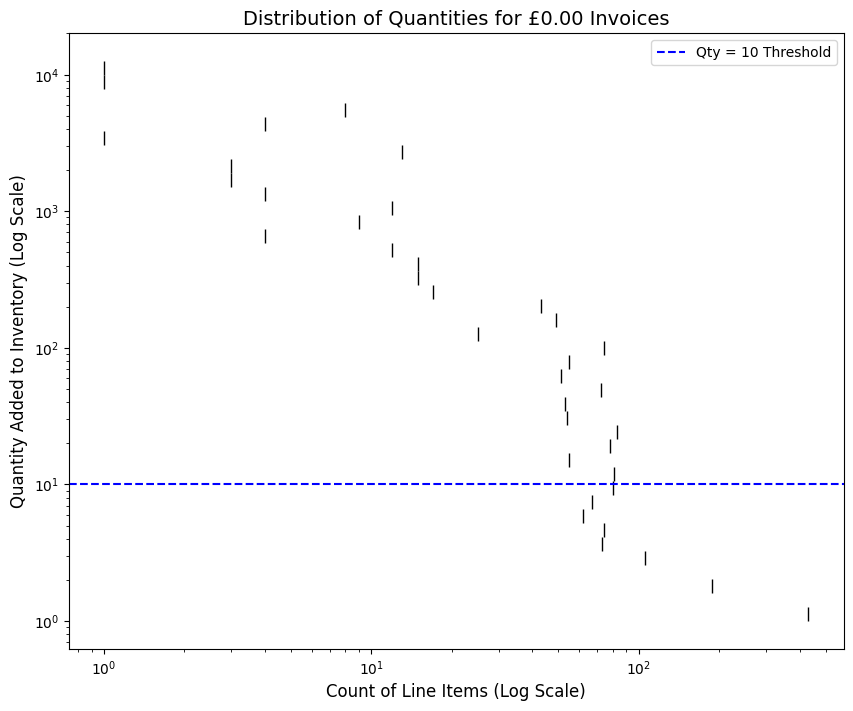

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the line items for the zero charge invoices
zero_invoice_list = zero_invoices['Invoice'].tolist()
df_zero_items = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(zero_invoice_list)]

# --- Check if these are Warehouse ---

# Check how many of these lack a CustomerHashID
missing_customer_count = df_zero_items['CustomerHashID'].isna().sum()
df_zero_items = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(zero_invoice_list)]
total_zeroed_items = len(df_zero_items)
print(f"Total 'Zero UnitPrice' Line Items: {total_zeroed_items}")
print(f"Items missing Customer ID: {missing_customer_count} ({(missing_customer_count/total_zeroed_items)*100:.1f}%)")

# Check if Invoice to StockCode is "One-to-One"
items_per_invoice = df_zero_items.groupby('Invoice').size()
single_item_invoices = (items_per_invoice == 1).sum()
total_zeroed_invs = len(items_per_invoice)
print(f"Invoices with only one line item: {single_item_invoices} out of {total_zeroed_invs} ({(single_item_invoices/total_zeroed_invs)*100:.1f}%)")

# Check Quantity thresholds
qty_over_10 = (df_zero_items['Quantity'] > 10).sum()
print(f"Items with Quantity > 10: {qty_over_10} ({(qty_over_10/total_zeroed_items)*100:.1f}%)")
print("-" * 60)

# --- Graph: Quantity Distribution ---

plt.figure(figsize=(10, 8))
# Use histogram with log scale to handle large numbers
ax = sns.histplot(data=df_zero_items, y='Quantity', bins=40, log_scale=(True, True))
plt.title('Distribution of Quantities for £0.00 Invoices', fontsize=14)
plt.ylabel('Quantity Added to Inventory (Log Scale)', fontsize=12)
plt.xlabel('Count of Line Items (Log Scale)', fontsize=12)

# Add a horizontal line at 10 to visually separate larger quantities that could indicate warehouse adjustments
plt.axhline(10, color='blue', linestyle='--', label='Qty = 10 Threshold')
plt.legend()
plt.show()

**The above graph shows a distibution of Inventory Line items where the total invoice price is £0.00:**
- In total we have 1,861 line items and they are counted in 40 buckets on the bottom axis.
- Since both "line item count per invoice" and "Inventory stock count = Quantity" range from 1 to thousands we use a log scale to count both and make visually clearer on the graph
- We add quantity of stock on the vertical axis and a blue line for 10 products of stock to definerentiate where Quantity gets bigger

Per the summary at the top, nearly all of these line items (99.5%) have no CustomerHashID and so are not associated to a customer and 96% of them are one-to-one on Invoice to Line Item. IE that it looks like someone has gone into the inventory to add Quantity +X against one product stock code that is unrelated to a customer transaction and added just one zero UnitPrice Invoice Line Item to account for it.

If we look to the top left of the graph we see some large stock nujmbers being entered few line items.

In conclusion we have two (main) scenarios:
1. mixed invoices where some line items are £0.00 but these are genuine customer orders
2. zero invoices where these clearly look like Warehouse Inventory Control (and which we want to flag)

In [17]:
# 1. Get a list of unique Invoices that have at least one item with UnitPrice = 0 and Quantity < 0
zero_price_items_minus = (df_cleansed_retail_orders['UnitPrice'] == 0) & (df_cleansed_retail_orders['Quantity'] < 0)
invoices_with_zero_items_minus = df_cleansed_retail_orders[zero_price_items_minus]['Invoice'].unique()

# 2. Filter the main dataset to get all line items for these invoices
df_target_invoices_minus = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(invoices_with_zero_items_minus)]

# 3. Group by Invoice and find the Maximum UnitPrice for each invoice
# If Max UnitPrice > 0, there are charges associated to the invoice
# If Max UnitPrice == 0, the entire order was £0.00
invoice_summary_minus = df_target_invoices_minus.groupby('Invoice')['UnitPrice'].max().reset_index()

# 4. Separate and count the two scenarios
mixed_invoices_minus = invoice_summary_minus[invoice_summary_minus['UnitPrice'] > 0]
zero_invoices_minus = invoice_summary_minus[invoice_summary_minus['UnitPrice'] == 0]

# --- Print the Results ---
print(f"Let's do the same sense check on for Quantity less than 0): {len(invoices_with_zero_items_minus)}")
print("-" * 60)
print(f"1. Mixed Invoices (At least one Zero price line item):  {len(mixed_invoices_minus)}")
print(f"2. ALL line items are £0.00:                            {len(zero_invoices_minus)}")

Let's do the same sense check on for Quantity less than 0): 3393
------------------------------------------------------------
1. Mixed Invoices (At least one Zero price line item):  0
2. ALL line items are £0.00:                            3393


---
We do the final check above for any mixed invoices with negative quantity. There aren't any they are all zero invoice line items.

We now use the above logic to create a cleanse rule to flag Warehouse Inventory Control, Add Stock / Remove Stock

**We Create the cleanse rule to add WarehouseInventory:**

---
---
---
---

In [11]:
df_stock_counts = df_cleansed_retail_orders.groupby('StockCode').size().reset_index(name='Total').sort_values('StockCode')
display(df_stock_counts.head(10))

,StockCode,Total
0,10002,400
1,10002R,3
2,10080,31
3,10109,2
4,10120,79
5,10123C,71
6,10123G,21
7,10124A,20
8,10124C,1
9,10124G,11


---
---
---
---
Export for Testing Script:

In [ ]:
# import os
# output_csv_path = '../data/interim/investigate.csv'
# to_investigate.to_csv(output_csv_path, index=False)

---
---
Test Large Prices for later:

In [ ]:
# We look at transactions where the absolute value is large
large_transactions = df_cleansed_retail_orders[df_cleansed_retail_orders['TotalPrice'].abs() > 10000]

display(large_transactions[['Invoice', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'TotalPrice', 'CustomerHashID', 'InvoiceDate']].sort_values('TotalPrice').sample(10))

---
## For the Distribution Analysis
- Also per the Kaggle Description, which we can see in the data with all the bulk orders, many customers are Wholesalers. So when it comes to grouping for feature engineering, we need to look at things like Basket Breadth, Bulk Quantity Behaviour, Return/Cancellation Rate and Categories of products would be along the lines of seasonal goods, home deco, events or party supplies etc.
- We would also see if we can split B2B from B2C and how guest checkout fits into this (there are many customer ID NaN which for online retail indicates adhoc shoppers who click and ship maybe for a one off event or trying out services our etc.). IE is there a way to identify and handle each group separately.



In [ ]:
# We look at transactions that are NOT product
Product_Descriptions = df_cleansed_retail_orders[df_cleansed_retail_orders['TransactionType'] == 'PRODUCT']
Product_List = Product_Descriptions['Description'].drop_duplicates().sort_values()
display(Product_List.sample(5))